# Modal analysis of a 2D truss cantilever
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/truss/modal.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/truss/modal.ipynb)

In [21]:
import matplotlib.pyplot as plt
import torch

from torchfem import Truss
from torchfem.materials import IsotropicElasticity1D

torch.set_default_dtype(torch.float64)

## Model setup

We build a 2-D truss cantilever with two chords and diagonal bracing,
clamped at the left edge.

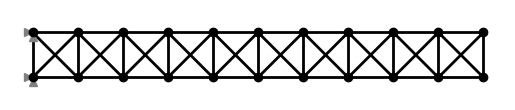

In [22]:
# Geometric parameters
L = 10.0
H = 1.0
n_x = 11

# Material and section properties
E = 1000.0
rho = 1.0
A = 0.05

# Build nodes on two chords
x = torch.linspace(0.0, L, n_x)
bottom = torch.stack([x, torch.zeros_like(x)], dim=1)
top = torch.stack([x, H * torch.ones_like(x)], dim=1)
nodes = torch.cat([bottom, top], dim=0)

# Connectivity: bottom chord, top chord, verticals, and two diagonal families
elements = []
for i in range(n_x - 1):
    elements.append([i, i + 1])
    elements.append([i + n_x, i + n_x + 1])
for i in range(n_x):
    elements.append([i, i + n_x])
for i in range(n_x - 1):
    elements.append([i, i + n_x + 1])
    elements.append([i + n_x, i + 1])
elements = torch.tensor(elements)

material = IsotropicElasticity1D(E=E, rho=rho)
model = Truss(nodes, elements, material)
model.areas[:] = A

# Clamp both left nodes
model.constraints[[0, n_x], :] = True

model.plot(node_labels=False)

## Modal analysis

Solve for the first six natural frequencies and mode shapes.

In [23]:
N = 6
omega_sq, modes = model.solve_modes(n_modes=N)

## Visualize mode shapes

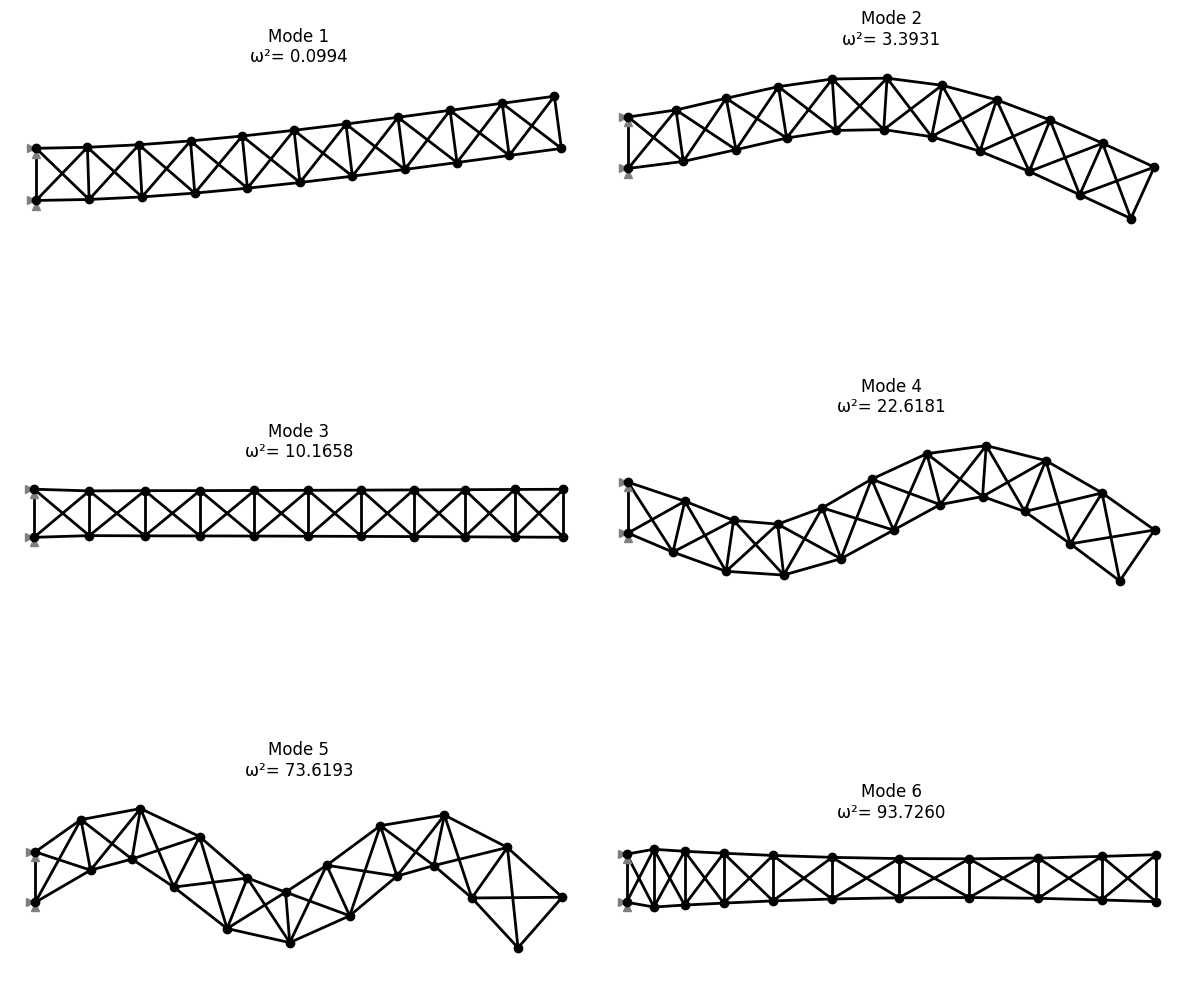

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()
for k in range(N):
    mode_k = modes[k]
    max_mag = torch.norm(mode_k, dim=1).max()
    u_plot = mode_k / max_mag
    model.plot(
        u=u_plot,
        ax=axes[k],
        node_labels=False,
        title=f"Mode {k + 1}\nω²= {float(omega_sq[k]):.4f}",
    )

plt.tight_layout()
plt.show()